## Training Spam Layer

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Load full spam dataset
spam_df = pd.read_csv('../data/processed/processed_spam.csv')
print(f"Shape: {spam_df.shape}")
print(f"Distribution: {spam_df['spam'].value_counts().to_dict()}")

Shape: (7865, 2)
Distribution: {0: 4238, 1: 3627}


In [2]:
X_train, X_val, y_train, y_val = train_test_split(
    spam_df['text'], spam_df['spam'],
    test_size=0.2, random_state=42, stratify=spam_df['spam']
)

print(f"Train: {len(X_train)} | Val: {len(X_val)}")

Train: 6292 | Val: 1573


              precision    recall  f1-score   support

    Not Spam       0.92      0.96      0.94       848
        Spam       0.95      0.90      0.92       725

    accuracy                           0.93      1573
   macro avg       0.93      0.93      0.93      1573
weighted avg       0.93      0.93      0.93      1573

ROC-AUC: 0.9774


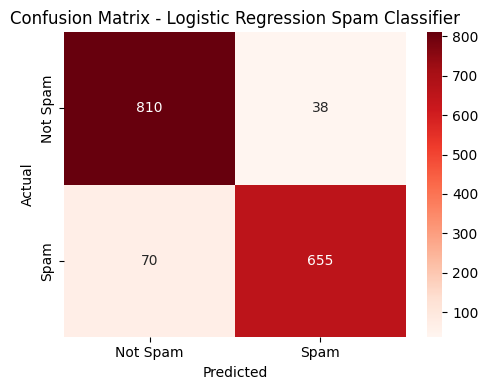

In [3]:
# Train
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

# Evaluate
y_pred = lr_pipeline.predict(X_val)
y_prob = lr_pipeline.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred, target_names=['Not Spam', 'Spam']))
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob):.4f}")

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.title('Confusion Matrix - Logistic Regression Spam Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Few legit comments get makred as spam, however we miss 10% of actual spam based on recall.

In [4]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'tfidf__max_features': [10000, 30000],
    'tfidf__ngram_range': [(1,2), (1,3)],
    'clf__C': [0.1, 1, 10],
    'clf__class_weight': [None, 'balanced']
}

grid = GridSearchCV(lr_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV F1: {grid.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'clf__C': 10, 'clf__class_weight': 'balanced', 'tfidf__max_features': 30000, 'tfidf__ngram_range': (1, 2)}
Best CV F1: 0.9239


In [5]:
lr_final = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=30000, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, C=10, class_weight='balanced'))
])

lr_final.fit(X_train, y_train)

y_pred_final = lr_final.predict(X_val)
y_prob_final = lr_final.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred_final, target_names=['Not Spam', 'Spam']))
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_final):.4f}")

              precision    recall  f1-score   support

    Not Spam       0.93      0.94      0.94       848
        Spam       0.93      0.92      0.93       725

    accuracy                           0.93      1573
   macro avg       0.93      0.93      0.93      1573
weighted avg       0.93      0.93      0.93      1573

ROC-AUC: 0.9834


Ok so we improved recall for spam, but had a drop in not-spam recval from 96 to 94. This means we are catching mosre spam at the cost of flagging a few legit comments for human review in our ssytem rather than auto approval. That is a fine tradeoff.

In [9]:
import pickle

with open('../models/spam_classifier.pkl', 'wb') as f:
    pickle.dump(lr_final, f)

print("Model saved to models/spam_classifier.pkl")

Model saved to models/spam_classifier.pkl
